In [58]:
# ============================================
# TELCO CUSTOMER CHURN ANALYSIS
# Author: Your Name
# Goal: Identify key drivers of customer churn
# and provide actionable business recommendations
# ============================================

# ---- 1. IMPORT LIBRARIES ----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

Saving Telco-Customer-Churn.xlsx to Telco-Customer-Churn (2).xlsx


In [59]:
# ============================================
# TELCO CUSTOMER CHURN ANALYSIS
# Analyzing customer retention risk and
# business insights
# ============================================

In [60]:
# ---- 2. LOAD THE DATASET ----
# Upload the file from your local machine
uploaded = files.upload()

# Read the Excel file into a Pandas DataFrame
df = pd.read_excel('Telco-Customer-Churn.xlsx')

# Preview the first 5 rows to confirm it loaded correctly
df.head()




Saving Telco-Customer-Churn.xlsx to Telco-Customer-Churn (3).xlsx


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [61]:
# ---- 3. EXPLORE THE DATASET ----
# Check column names, data types, and non-null counts
# This helps us understand what we are working with
# and spot any data quality issues early
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [62]:
# ---- 4. CLEAN THE DATA ----

# TotalCharges came in as an object (text) instead of a number
# We convert it to numeric and coerce any errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls were created after conversion
print(f"Null values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Drop rows where TotalCharges could not be converted
# These are likely new customers with no charges yet
df = df.dropna(subset=['TotalCharges'])

# Create a numeric churn flag for calculations
# Yes = 1 (churned), No = 0 (retained)
df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Display the overall churn rate as a percentage
churn_rate = df['ChurnFlag'].mean()
print(f"Overall Churn Rate: {churn_rate:.1%}")

Null values in TotalCharges: 11
Overall Churn Rate: 26.6%


In [63]:
# ---- 5. CHURN BY CONTRACT TYPE ----
# Customers on month-to-month contracts
# tend to have less commitment to the service
# Let's see if that shows up in the churn data

contract_churn = df.groupby('Contract')['ChurnFlag'].mean()
print("Churn Rate by Contract Type:")
print(contract_churn.apply(lambda x: f"{x:.1%}"))

Churn Rate by Contract Type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: ChurnFlag, dtype: object


In [64]:
# ---- 6. CHURN BY INTERNET SERVICE ----
# Different internet service types may have
# different satisfaction levels or pricing
# which could influence a customer's decision to leave

internet_churn = df.groupby('InternetService')['ChurnFlag'].mean()
print("Churn Rate by Internet Service Type:")
print(internet_churn.apply(lambda x: f"{x:.1%}"))

Churn Rate by Internet Service Type:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: ChurnFlag, dtype: object


In [65]:
# ---- 7. CHURN BY PAYMENT METHOD ----
# Payment method can be a signal of customer engagement
# Automatic payments may indicate more committed customers

payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].mean()
print("Churn Rate by Payment Method:")
print(payment_churn.apply(lambda x: f"{x:.1%}"))

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7%
Credit card (automatic)      15.3%
Electronic check             45.3%
Mailed check                 19.2%
Name: ChurnFlag, dtype: object


In [66]:
# ---- 8. AVERAGE TENURE BY CHURN STATUS ----
# We expect churned customers to have shorter tenure
# This confirms whether loyal customers stay longer

tenure_churn = df.groupby('ChurnFlag')['tenure'].mean()
print("Average Tenure by Churn Status (months):")
print(f"Retained customers: {tenure_churn[0]:.1f} months")
print(f"Churned customers:  {tenure_churn[1]:.1f} months")

Average Tenure by Churn Status (months):
Retained customers: 37.7 months
Churned customers:  18.0 months


In [67]:
# ---- 9. CHURN BY TECH SUPPORT AND CONTRACT ----
# Tech support availability combined with contract type
# may reveal whether service quality affects retention

print("Churn Rate by Tech Support and Contract Type:")
print(df.groupby(['TechSupport', 'Contract'])['ChurnFlag'].mean().apply(lambda x: f"{x:.1%}"))

Churn Rate by Tech Support and Contract Type:
TechSupport          Contract      
No                   Month-to-month    50.4%
                     One year          14.7%
                     Two year           6.0%
No internet service  Month-to-month    18.9%
                     One year           2.5%
                     Two year           0.8%
Yes                  Month-to-month    30.7%
                     One year          13.6%
                     Two year           3.5%
Name: ChurnFlag, dtype: object


In [68]:
# ---- 10. CHURN BY ONLINE SECURITY AND INTERNET SERVICE ----
# Customers without online security may feel less
# protected and be more likely to switch providers

print("Churn Rate by Online Security and Internet Service:")
print(df.groupby(['OnlineSecurity', 'InternetService'])['ChurnFlag'].mean().apply(lambda x: f"{x:.1%}"))

Churn Rate by Online Security and Internet Service:
OnlineSecurity       InternetService
No                   DSL                28.0%
                     Fiber optic        49.4%
No internet service  No                  7.4%
Yes                  DSL                 9.5%
                     Fiber optic        21.8%
Name: ChurnFlag, dtype: object


In [69]:
# ---- 11. AVERAGE MONTHLY AND TOTAL CHARGES BY CHURN ----
# Higher monthly charges may push customers to leave
# Lower total charges for churned customers reflects shorter tenure

print(f"Average Monthly Charges:")
print(f"Retained: ${df[df['ChurnFlag']==0]['MonthlyCharges'].mean():.2f}")
print(f"Churned:  ${df[df['ChurnFlag']==1]['MonthlyCharges'].mean():.2f}")

print(f"\nAverage Total Charges:")
print(f"Retained: ${df[df['Churn']=='No']['TotalCharges'].mean():.2f}")
print(f"Churned:  ${df[df['Churn']=='Yes']['TotalCharges'].mean():.2f}")

Average Monthly Charges:
Retained: $61.31
Churned:  $74.44

Average Total Charges:
Retained: $2555.34
Churned:  $1531.80


In [70]:
# ---- 12. CHURN BY TENURE GROUP ----
# Grouping customers by how long they have been with the company
# helps identify at what stage customers are most likely to leave

df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0,6,12,24,72],
                             labels=['0-6','6-12','12-24','24+'])

tenure_group_churn = df.groupby('tenure_group', observed=False)['ChurnFlag'].mean()
print("Churn Rate by Tenure Group:")
print(tenure_group_churn.apply(lambda x: f"{x:.1%}"))

Churn Rate by Tenure Group:
tenure_group
0-6      53.3%
6-12     35.9%
12-24    28.7%
24+      14.0%
Name: ChurnFlag, dtype: object


In [71]:
# ---- 13. HIGH RISK CUSTOMER SEGMENT ANALYSIS ----
# Combining the highest risk factors identified above
# to find the single most at-risk customer profile

# Highest risk: Month-to-month + Fiber optic + Electronic check
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
]['ChurnFlag'].mean()

# Medium risk: Month-to-month + DSL + Electronic check
medium_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'DSL') &
    (df['PaymentMethod'] == 'Electronic check')
]['ChurnFlag'].mean()

# Lower risk: Month-to-month + No internet + Electronic check
lower_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'No') &
    (df['PaymentMethod'] == 'Electronic check')
]['ChurnFlag'].mean()

print("High Risk Segment Analysis (Month-to-month + Electronic check):")
print(f"Fiber optic internet: {high_risk:.1%} churn rate -- HIGHEST RISK")
print(f"DSL internet:         {medium_risk:.1%} churn rate -- MEDIUM RISK")
print(f"No internet:          {lower_risk:.1%} churn rate -- LOWER RISK")

High Risk Segment Analysis (Month-to-month + Electronic check):
Fiber optic internet: 60.4% churn rate -- HIGHEST RISK
DSL internet:         40.5% churn rate -- MEDIUM RISK
No internet:          18.8% churn rate -- LOWER RISK


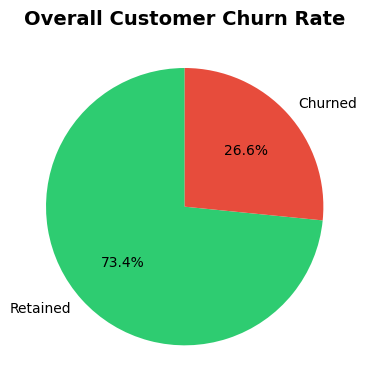

In [72]:
# Overall churn rate
plt.figure(figsize=(6,4))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(churn_counts, labels=['Retained', 'Churned'],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Overall Customer Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1998/1019407234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='ChurnFlag', palette='Reds_r')


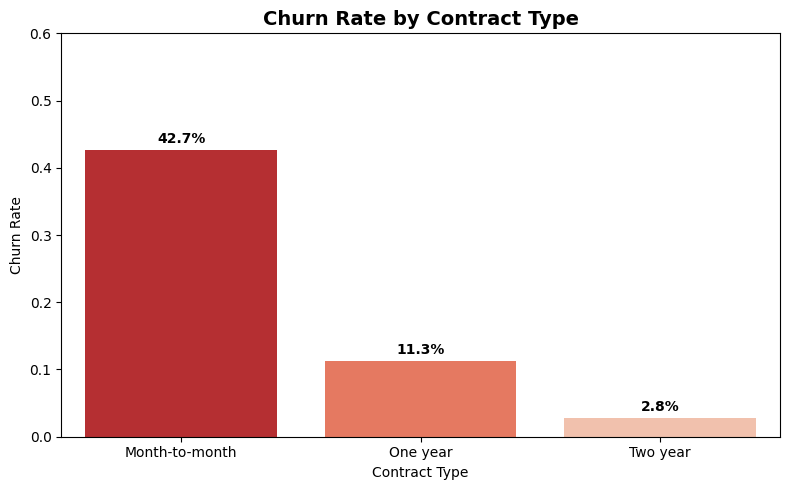

In [73]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['ChurnFlag'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=contract_churn, x='Contract', y='ChurnFlag', palette='Reds_r')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.6)
for i, row in contract_churn.iterrows():
    plt.text(i, row['ChurnFlag'] + 0.01, f"{row['ChurnFlag']:.1%}",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1998/2680673974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_churn, x='tenure_group', y='ChurnFlag', palette='Blues_r')


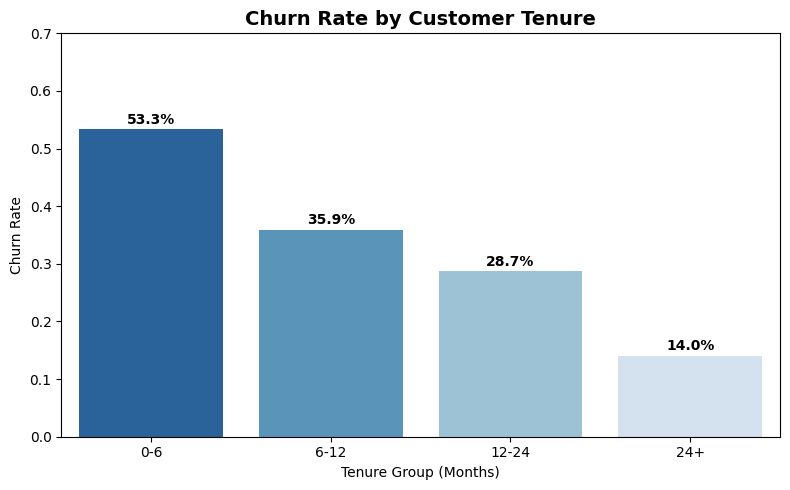

In [74]:
# Churn rate by tenure group
tenure_churn = df.groupby('tenure_group', observed=False)['ChurnFlag'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=tenure_churn, x='tenure_group', y='ChurnFlag', palette='Blues_r')
plt.title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.7)
for i, row in tenure_churn.iterrows():
    plt.text(i, row['ChurnFlag'] + 0.01, f"{row['ChurnFlag']:.1%}",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

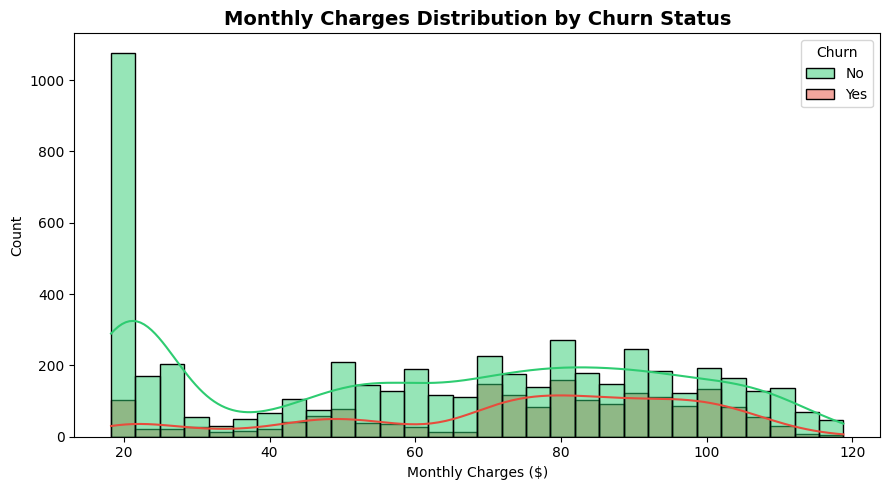

In [75]:
# Monthly charges by churn status
plt.figure(figsize=(9,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             bins=30, kde=True, palette={'Yes':'#e74c3c', 'No':'#2ecc71'})
plt.title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1998/931363058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_churn, x='PaymentMethod', y='ChurnFlag', palette='Oranges_r')


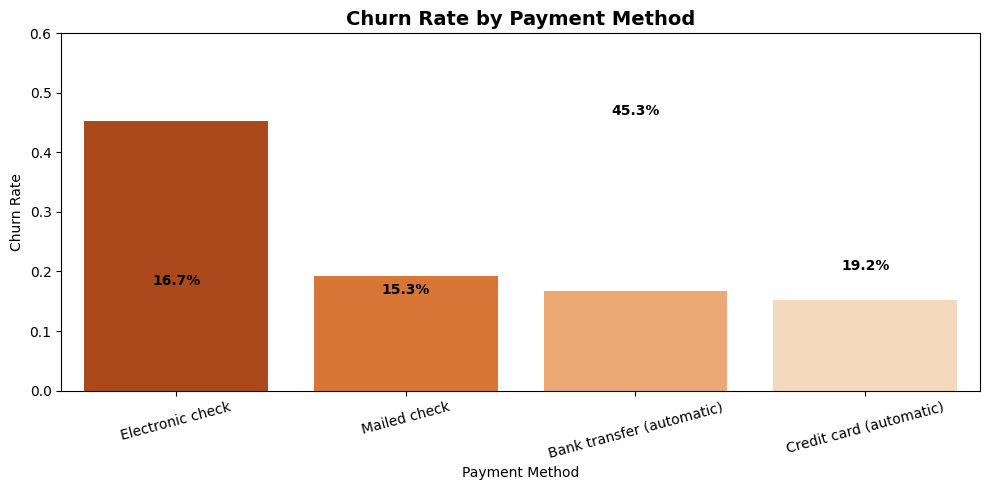

In [76]:
# Churn by payment method
payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].mean().reset_index()
payment_churn = payment_churn.sort_values('ChurnFlag', ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=payment_churn, x='PaymentMethod', y='ChurnFlag', palette='Oranges_r')
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=15)
plt.ylim(0, 0.6)
for i, row in payment_churn.iterrows():
    plt.text(i, row['ChurnFlag'] + 0.01, f"{row['ChurnFlag']:.1%}",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

# Key Business Insights and Recommendations

## What the Data Tells Us

1. **Overall churn rate is 26.6%** -- meaning roughly 1 in 4 customers leaves

2. **Month-to-month contracts are the biggest risk** -- 42.7% churn rate vs just 2.8% for two year contracts. The business should prioritize converting monthly customers to longer contracts.

3. **New customers churn fastest** -- customers in their first 6 months churn at 53.3%. An onboarding improvement program targeting the first 90 days could significantly reduce early churn.

4. **Electronic check users churn at 45.3%** -- the highest of any payment method. Incentivizing automatic payment methods could reduce churn meaningfully.

5. **Fiber optic internet customers churn at 41.9%** -- nearly double the DSL rate. This suggests a potential service quality or pricing issue worth investigating.

6. **Highest risk segment: Month-to-month + Fiber optic + Electronic check** -- these customers churn at 60.4%. This group should be the first target for a retention campaign.

## Recommended Business Actions

- Launch a contract upgrade incentive program targeting month-to-month customers in their first 6 months
- Offer a discount for switching from electronic check to automatic payment
- Investigate fiber optic service quality and pricing competitiveness
- Build a customer health score model to proactively flag high risk customers before they churn